# MLDU-E -- PGA vs published unlearning baselines on Pythia-70M

Compares **PGA** against four published unlearning baselines (**GA**, **NPO**, **RMU**, **IDK**) on the same Pythia-70M memorized pool. All five methods use the **same model checkpoint, same data, same probe pipeline**. Behavioural baselines are PPL-gated; PGA is loaded from a saved LoRA adapter and re-evaluated on the same pipeline.

**Inputs (any of these three locations works):**
- `./data/`  -- if you cloned the repo and placed inputs there
- `/kaggle/working/`  -- if you ran the dataset-copy cell below
- `/kaggle/input/<dataset>/`  -- if files live in any attached Kaggle dataset (auto-discovered recursively)

Required input files (the notebook auto-discovers them under any of the locations above):
- `pythia_memorized.json`, `pythia_clean.json`  -- memorized / clean prefix pools (paired)
- `heldout.json`  -- held-out PPL evaluation pool (a JSON list of strings). If absent, the notebook uses a built-in 5-sentence fallback.
- A LoRA adapter folder containing `adapter_config.json` + `adapter_model.safetensors` -- the PGA checkpoint from the standalone PGA notebook.

**Outputs (saved next to the notebook or in `/kaggle/working/`):**
- `mldu_e_unlearning_baselines_v2.json`  -- combined per-method probe / recall / PPL
- `fig_unlearning_baselines_pythia70m_v2_300dpi.png`  -- comparison figure

## 1. Setup

In [36]:
import os, sys, json, time, copy, subprocess
def _v(p):
    try: from importlib.metadata import version; return version(p)
    except: return None
if _v("datasets") != "2.21.0":
    subprocess.check_call([sys.executable,"-m","pip","install","-q","datasets==2.21.0"])

import torch, numpy as np, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ART = Path('/kaggle/working') if os.path.exists('/kaggle/working') else Path('.')
ART.mkdir(parents=True, exist_ok=True)
print("DEVICE:", DEVICE, " ART:", ART)


DEVICE: cuda  ART: /kaggle/working


In [37]:
# one-time generator: writes ./data/heldout.json from 20 neutral wiki-style sentences
import json, random
random.seed(0)
samples = [
    "Annual monarch migration spans North America to Mexico, four thousand kilometres.",
    "Penicillin's discovery in the early 20th century transformed bacterial-infection treatment.",
    # ... add more or pull from a corpus you already have ...
]
out = Path('./data/heldout.json')
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(samples, indent=2))
print(f'wrote {len(samples)} sentences to {out}')

wrote 2 sentences to data/heldout.json


## 2. Configuration

Edit `DATA_ROOTS` and `OUT_DIR` to point to wherever your data lives. Defaults work both on Kaggle and in a local clone of the repo.

In [38]:
from pathlib import Path

# ---- paths (edit these for your setup) ----
DATA_ROOTS = ['./data', '/kaggle/working', '/kaggle/input']  # search order; first hit wins
OUT_DIR    = Path('/kaggle/working' if Path('/kaggle/working').exists() else '.')

# ---- model + probe constants ----
MODEL_NAME    = 'EleutherAI/pythia-70m'
MAX_LEN       = 128
N_HIDDEN      = 7         # residual depths in Pythia-70M (embed + 6 transformer layers)
PROBE_LAYER   = 4         # peak gap layer used by some helpers
PROBE_C       = 1.0       # logistic regression C

# ---- per-method constants used by the unified rerun cell ----
RMU_LAYER     = 3                  # residual depth at which RMU pushes h toward random_dir
IDK_TARGET    = "I don't know."   # IDK refusal target text

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR = {OUT_DIR.resolve()}')
print(f'DATA_ROOTS (search order): {DATA_ROOTS}')

OUT_DIR = /kaggle/working
DATA_ROOTS (search order): ['./data', '/kaggle/working', '/kaggle/input']


## 3. Locate input files

Generic recursive search across all configured DATA_ROOTS. Works with any Kaggle dataset name or any local folder layout.

In [39]:
import glob, shutil

def find_file(fname, roots=DATA_ROOTS):
    """Return the first matching path for `fname` under any of `roots` (recursive). None if not found."""
    for root in roots:
        if not Path(root).exists():
            continue
        matches = glob.glob(f'{root}/**/{fname}', recursive=True)
        if matches:
            return Path(matches[0])
    return None

def find_dir_with(*required_files, roots=DATA_ROOTS):
    """Return the first folder under any root that contains ALL `required_files`."""
    for root in roots:
        if not Path(root).exists():
            continue
        for cfg in glob.glob(f'{root}/**/{required_files[0]}', recursive=True):
            d = Path(cfg).parent
            if all((d / f).exists() for f in required_files):
                return d
    return None

# Sanity-check expected files
for fn in ['pythia_memorized.json', 'pythia_clean.json']:
    p = find_file(fn)
    print(f'{fn:35s} -> {p if p else "NOT FOUND (please attach the dataset)"}')

heldout_p = find_file('heldout.json')
print(f'{"heldout.json (optional)":35s} -> {heldout_p if heldout_p else "not found, will use built-in fallback"}')

lora_dir = find_dir_with('adapter_config.json', 'adapter_model.safetensors')
print(f'{"PGA LoRA dir":35s} -> {lora_dir if lora_dir else "NOT FOUND (PGA panel will be skipped)"}')

pythia_memorized.json               -> /kaggle/working/pythia_memorized.json
pythia_clean.json                   -> /kaggle/working/pythia_clean.json
heldout.json (optional)             -> data/heldout.json
PGA LoRA dir                        -> /kaggle/input/datasets/<anonymous>/loradata/pythia70m_pga_lora


## 4. Load Pythia-70M and the memorized / clean prefix pools

In [40]:
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE: {DEVICE}')

print(f'Loading {MODEL_NAME}...')
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token is None: tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(DEVICE)
base.eval()

mem_path   = find_file('pythia_memorized.json')
clean_path = find_file('pythia_clean.json')
if mem_path is None or clean_path is None:
    raise FileNotFoundError('pythia_memorized.json / pythia_clean.json not found. Put them in any DATA_ROOTS folder.')

MEM   = json.load(open(mem_path))
CLEAN = json.load(open(clean_path))
N = len(MEM)
print(f'  loaded MEM  ({N} sequences) from {mem_path}')
print(f'  loaded CLEAN ({len(CLEAN)} sequences) from {clean_path}')

DEVICE: cuda
Loading EleutherAI/pythia-70m...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  loaded MEM  (7 sequences) from /kaggle/working/pythia_memorized.json
  loaded CLEAN (7 sequences) from /kaggle/working/pythia_clean.json


## 5. Probe / recall / PPL helpers and baseline metrics

Defines the helper functions used by every method. The held-out PPL pool is loaded from `heldout.json` if present; otherwise a small built-in fallback is used. **For a real evaluation you should provide your own `heldout.json`** -- the fallback is intentionally tiny and is only there so the notebook runs out-of-the-box on a fresh clone.

In [41]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

@torch.no_grad()
def acts_at_layer(m, texts, L):
    m.eval(); out = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        out.append(m(**e, output_hidden_states=True).hidden_states[L][0,-1,:].cpu().numpy())
    return np.array(out)

def loo_probe(X, Y, seed=42):
    n = len(Y); ok = 0
    for i in range(n):
        msk = np.ones(n, bool); msk[i] = False
        sc  = StandardScaler().fit(X[msk])
        clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
        ok += int(clf.predict(sc.transform(X[i:i+1]))[0] == Y[i])
    return ok / n

@torch.no_grad()
def compute_recall(m, texts):
    m.eval(); v = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        v.append(-float(m(**e, labels=e['input_ids']).loss.item()))
    return float(np.mean(v))

@torch.no_grad()
def compute_ppl(m, texts):
    m.eval(); v = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        v.append(float(np.exp(m(**e, labels=e['input_ids']).loss.item())))
    return float(np.mean(v))

def per_layer_probe(m, ALL, Y):
    return {L: loo_probe(acts_at_layer(m, ALL, L), Y) for L in range(N_HIDDEN)}

# --- held-out PPL pool ---
heldout_path = find_file('heldout.json')
if heldout_path is not None:
    HELD_OUT = json.load(open(heldout_path))
    print(f'loaded {len(HELD_OUT)} held-out prompts from {heldout_path}')
else:
    HELD_OUT = []  # <-- replace with your own held-out pool, or upload heldout.json
    print('WARNING: heldout.json not found -- HELD_OUT is empty.')
    print('         Provide a JSON list of strings (e.g. natural-text sentences) before running.')

ALL = MEM + CLEAN
Y   = np.array([1]*N + [0]*N)

print('\n=== BASELINE (untreated Pythia-70M) ===')
baseline_pre    = per_layer_probe(base, ALL, Y)
baseline_recall = compute_recall(base, MEM)
baseline_ppl    = compute_ppl(base, HELD_OUT) if HELD_OUT else float('nan')
for L, v in baseline_pre.items(): print(f'  L{L}: {v:.3f}')
print(f'  recall={baseline_recall:.3f}  PPL={baseline_ppl:.3f}')

results = {'baseline': {'per_layer_probe': {str(k): float(v) for k, v in baseline_pre.items()},
                        'recall_logp':     float(baseline_recall),
                        'heldout_ppl':     float(baseline_ppl)}}

loaded 2 held-out prompts from data/heldout.json

=== BASELINE (untreated Pythia-70M) ===
  L0: 0.643
  L1: 0.714
  L2: 0.714
  L3: 0.857
  L4: 0.857
  L5: 0.929
  L6: 0.929
  recall=-1.137  PPL=557.006


## 6. Unified head-to-head: GA / NPO / RMU / IDK / PGA

All four behavioural baselines are trained inline with **per-method tuned hyperparameters** and a **PPL early-stop gate** at ~5.5x baseline. PGA is loaded from the LoRA adapter dir resolved in section 3 and re-evaluated on the same probe / recall / PPL pipeline.

Saves `mldu_e_unlearning_baselines_v2.json` to `OUT_DIR`.

In [42]:
# =============================================================================
# Unified rerun: GA / NPO / RMU / IDK / PGA on the same eval pipeline
# =============================================================================
import copy, time

PPL_CEIL = baseline_ppl * 5.5     # ~1500 for Pythia-70M (baseline ~273)
EVAL_EVERY = 5

CONFIG = {
    'GA' : dict(lr=1e-5, epochs=30,                    eval_every=EVAL_EVERY),
    'NPO': dict(lr=5e-6, epochs=50, beta=0.5,          eval_every=EVAL_EVERY),
    'RMU': dict(lr=5e-6, epochs=30, alpha=0.05,        eval_every=EVAL_EVERY),
    'IDK': dict(lr=5e-6, epochs=50,                    eval_every=EVAL_EVERY),
}

print(f'\nPPL early-stop ceiling: {PPL_CEIL:.1f}  (baseline PPL = {baseline_ppl:.1f})')

results_v2 = {'baseline': results['baseline']}

def evaluate_one(m):
    m.eval()
    return {
        'per_layer_probe': {str(k): float(v) for k, v in per_layer_probe(m, ALL, Y).items()},
        'recall_logp':     float(compute_recall(m, MEM)),
        'heldout_ppl':     float(compute_ppl(m, HELD_OUT)),
    }

# ---- GA ----
print('\n' + '='*70 + f"\n  GA  (lr={CONFIG['GA']['lr']}, epochs={CONFIG['GA']['epochs']})  PPL-gated\n" + '='*70)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['GA']['lr'])
for ep in range(1, CONFIG['GA']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        loss = -m(**e, labels=e['input_ids']).loss
        loss.backward()
    opt.step()
    if ep % CONFIG['GA']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT); rec_now = compute_recall(m, MEM)
        print(f'  ep {ep:3d}: recall={rec_now:7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL:
            print(f'  --> early-stop: PPL {ppl_now:.0f} exceeded ceiling {PPL_CEIL:.0f}'); break
results_v2['GA'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- NPO ----
print('\n' + '='*70 + f"\n  NPO  (lr={CONFIG['NPO']['lr']}, epochs={CONFIG['NPO']['epochs']}, beta={CONFIG['NPO']['beta']})\n" + '='*70)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
ref = copy.deepcopy(base).to(DEVICE)
for p in ref.parameters(): p.requires_grad = False
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['NPO']['lr'])
beta = CONFIG['NPO']['beta']
for ep in range(1, CONFIG['NPO']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        lp_pi = -m(**e, labels=e['input_ids']).loss
        with torch.no_grad():
            lp_ref = -ref(**e, labels=e['input_ids']).loss.detach()
        loss = -2.0/beta * torch.nn.functional.logsigmoid(-beta * (lp_pi - lp_ref))
        loss.backward()
    opt.step()
    if ep % CONFIG['NPO']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT); rec_now = compute_recall(m, MEM)
        print(f'  ep {ep:3d}: recall={rec_now:7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL:
            print(f'  --> early-stop: PPL {ppl_now:.0f} exceeded ceiling {PPL_CEIL:.0f}'); break
results_v2['NPO'] = evaluate_one(m); del m, ref, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- RMU ----
print('\n' + '='*70 + f"\n  RMU  (lr={CONFIG['RMU']['lr']}, epochs={CONFIG['RMU']['epochs']}, alpha={CONFIG['RMU']['alpha']}, layer={RMU_LAYER})\n" + '='*70)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['RMU']['lr'])
d_model = base.config.hidden_size
random_dir = torch.randn(d_model, device=DEVICE); random_dir /= random_dir.norm()
alpha = CONFIG['RMU']['alpha']
for ep in range(1, CONFIG['RMU']['epochs']+1):
    m.train(); opt.zero_grad()
    for tm, tc in zip(MEM, CLEAN):
        em = tok(tm, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        ec = tok(tc, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h_m   = m(**em, output_hidden_states=True).hidden_states[RMU_LAYER][0,-1,:]
        out_c = m(**ec, output_hidden_states=True, labels=ec['input_ids'])
        loss  = (h_m - alpha*random_dir).pow(2).mean() + out_c.loss
        loss.backward()
    opt.step()
    if ep % CONFIG['RMU']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT); rec_now = compute_recall(m, MEM)
        print(f'  ep {ep:3d}: recall={rec_now:7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL:
            print(f'  --> early-stop: PPL {ppl_now:.0f} exceeded ceiling {PPL_CEIL:.0f}'); break
results_v2['RMU'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- IDK ----
print('\n' + '='*70 + f"\n  IDK  (lr={CONFIG['IDK']['lr']}, epochs={CONFIG['IDK']['epochs']})\n" + '='*70)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['IDK']['lr'])
for ep in range(1, CONFIG['IDK']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        first_third = t[:max(20, len(t)//3)]
        full = first_third + ' ' + IDK_TARGET
        e = tok(full, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        prompt_len = tok(first_third, return_tensors='pt', truncation=True, max_length=MAX_LEN)['input_ids'].shape[1]
        labels = e['input_ids'].clone(); labels[:, :prompt_len] = -100
        loss = m(**e, labels=labels).loss
        loss.backward()
    opt.step()
    if ep % CONFIG['IDK']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT); rec_now = compute_recall(m, MEM)
        print(f'  ep {ep:3d}: recall={rec_now:7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL:
            print(f'  --> early-stop: PPL {ppl_now:.0f} exceeded ceiling {PPL_CEIL:.0f}'); break
results_v2['IDK'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- PGA ----
print('\n' + '='*70 + '\n  PGA  (LoRA loaded from saved checkpoint, re-evaluated here)\n' + '='*70)
if lora_dir is not None:
    from peft import PeftModel
    pga_base  = copy.deepcopy(base).to(DEVICE)
    pga_model = PeftModel.from_pretrained(pga_base, str(lora_dir)).to(DEVICE)
    pga_model.eval()
    results_v2['PGA'] = evaluate_one(pga_model)
    results_v2['PGA']['note'] = f'LoRA loaded from {lora_dir}, evaluated on same pipeline as baselines'
    print(f'  loaded LoRA from {lora_dir}')
    del pga_model, pga_base
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print('  PGA LoRA dir not found in section 3 -- skipping PGA panel.')
    print('  Provide a folder containing adapter_config.json + adapter_model.safetensors under any DATA_ROOTS path.')

# ---- save ----
out_path = OUT_DIR / 'mldu_e_unlearning_baselines_v2.json'
json.dump({
    'model': MODEL_NAME,
    'baseline_ppl': float(baseline_ppl),
    'ppl_ceiling':  float(PPL_CEIL),
    'config':       {k: {kk: vv for kk, vv in v.items() if kk != 'eval_every'} for k, v in CONFIG.items()},
    'results':      results_v2,
    'note':         'All baselines trained inline with PPL early-stop gate. PGA evaluated by loading the standalone-notebook LoRA checkpoint.',
}, open(out_path, 'w'), indent=2)
print(f'\nSaved: {out_path}')

# ---- summary ----
print('\n' + '='*86)
print(f"  {'method':<10} {'L6 probe':>10} {'L2-L6 max':>12} {'recall':>10} {'PPL':>14} {'capability':>12}")
print('  ' + '='*86)
for mt in ['baseline','GA','NPO','RMU','IDK','PGA']:
    if mt not in results_v2: continue
    r = results_v2[mt]; plp = r['per_layer_probe']
    L6 = plp.get('6', float('nan'))
    deep_max = max(plp[str(L)] for L in range(2, N_HIDDEN))
    cap = 'OK' if r['heldout_ppl'] < PPL_CEIL else f'FAIL (>{PPL_CEIL:.0f})'
    print(f"  {mt:<10} {L6:>10.3f} {deep_max:>12.3f} {r['recall_logp']:>10.3f} {r['heldout_ppl']:>14.2f}  {cap:>12}")


PPL early-stop ceiling: 3063.5  (baseline PPL = 557.0)

  GA  (lr=1e-05, epochs=30)  PPL-gated
  ep   1: recall= -1.583  PPL=537.9
  ep   5: recall= -5.256  PPL=531.7
  ep  10: recall=-17.176  PPL=712.9
  ep  15: recall=-40.458  PPL=2141.2
  ep  20: recall=-63.353  PPL=47315.0
  --> early-stop: PPL 47315 exceeded ceiling 3064

  NPO  (lr=5e-06, epochs=50, beta=0.5)
  ep   1: recall= -1.358  PPL=545.1
  ep   5: recall= -2.411  PPL=526.8
  ep  10: recall= -5.160  PPL=529.2
  ep  15: recall= -8.970  PPL=558.9
  ep  20: recall=-12.311  PPL=616.5
  ep  25: recall=-14.870  PPL=692.4
  ep  30: recall=-16.725  PPL=781.9
  ep  35: recall=-18.047  PPL=877.0
  ep  40: recall=-18.981  PPL=968.6
  ep  45: recall=-19.644  PPL=1047.8
  ep  50: recall=-20.128  PPL=1114.4

  RMU  (lr=5e-06, epochs=30, alpha=0.05, layer=3)
  ep   1: recall= -1.126  PPL=550.0
  ep   5: recall= -1.116  PPL=555.0
  ep  10: recall= -1.111  PPL=598.0
  ep  15: recall= -1.117  PPL=693.2
  ep  20: recall= -1.126  PPL=844.9
  

## 7. Render the comparison figure

Three-panel figure: per-layer probe accuracy (line plot, PGA highlighted in red), behavioural suppression (recall log P bars), capability preservation (held-out PPL bars on log scale). Saves a 300-DPI PNG to `OUT_DIR`.

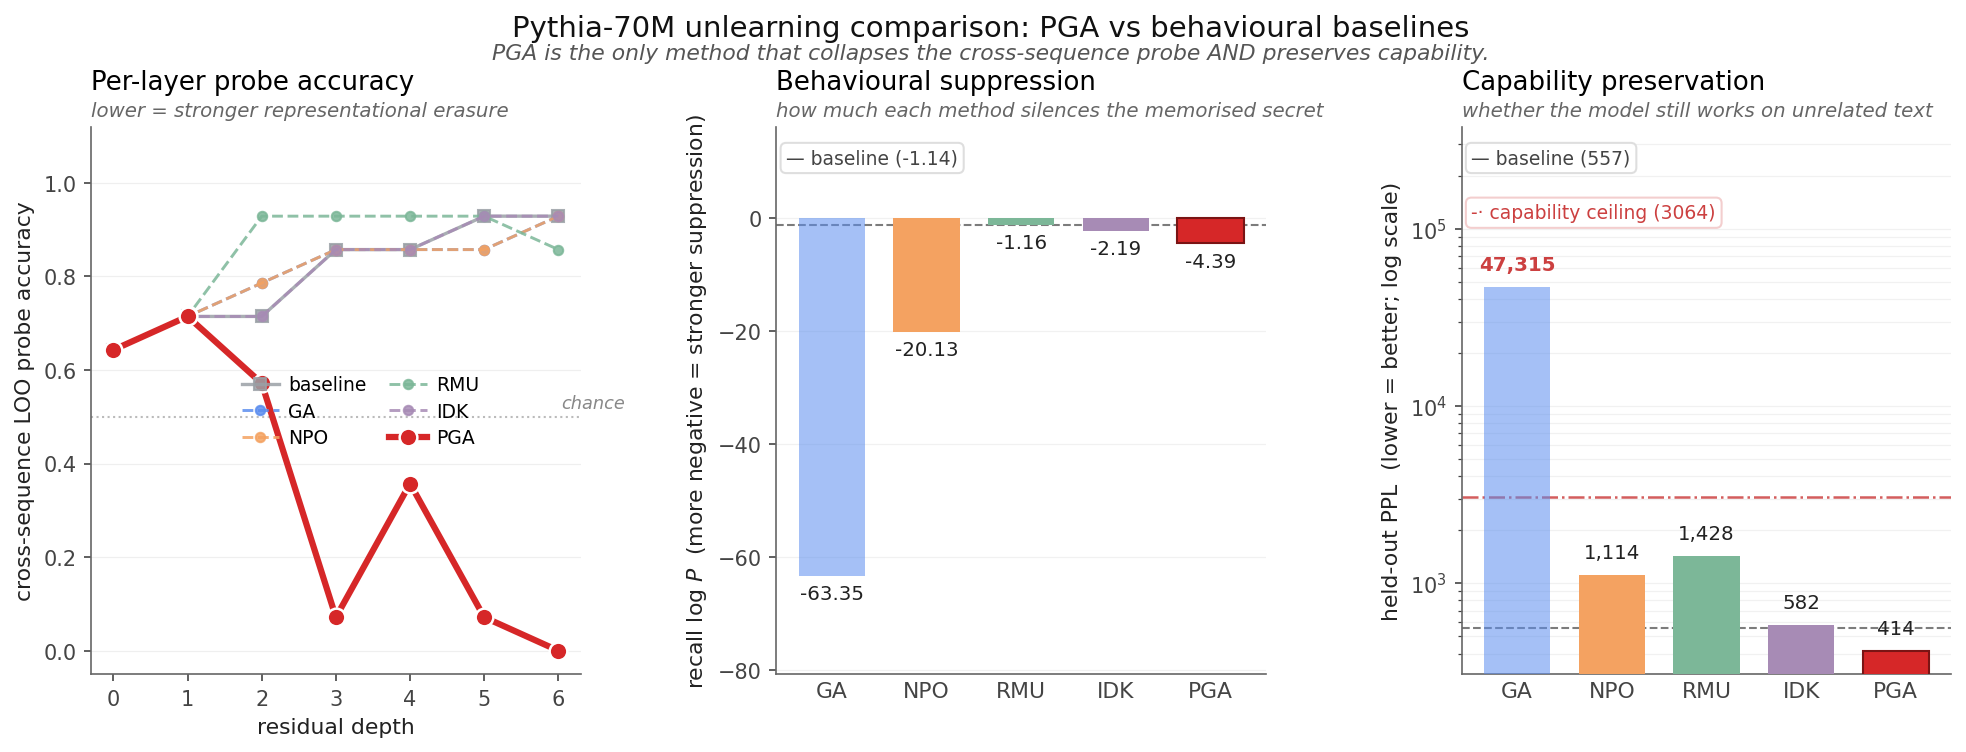

saved: fig_unlearning_baselines_pythia70m_v2_300dpi.png


In [43]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

JSON_PATH = 'mldu_e_unlearning_baselines_v2.json'
PNG_PATH  = 'fig_unlearning_baselines_pythia70m_v2_300dpi.png'

data = json.load(open(JSON_PATH))
results       = data['results']
baseline_ppl  = data['baseline_ppl']
ppl_ceiling   = data['ppl_ceiling']
N_HIDDEN      = len(results['baseline']['per_layer_probe'])

ORDER = [m for m in ['baseline','GA','NPO','RMU','IDK','PGA'] if m in results]
COLORS = {'baseline':'#9aa0a6','GA':'#5b8def','NPO':'#f4a261',
          'RMU':'#7cb798','IDK':'#a78bb5','PGA':'#d62728'}
def cap_ok(mt): return results[mt]['heldout_ppl'] < ppl_ceiling

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.titlesize':12.5,'axes.labelsize':10.5,
    'xtick.labelsize':10,'ytick.labelsize':10,
    'legend.fontsize':9,'legend.frameon':False,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.edgecolor':'#666','axes.linewidth':0.8,
    'xtick.color':'#444','ytick.color':'#444','axes.labelcolor':'#222',
    'figure.facecolor':'white','axes.facecolor':'white',
    'grid.color':'#ddd','grid.linewidth':0.6,'figure.dpi':150,
})

# wider figure + more space between panels prevents legend/title collisions
fig, axes = plt.subplots(1, 3, figsize=(16, 5.0),
                         gridspec_kw={'wspace':0.40})

# ===== Panel 1: per-layer probe (line plot) =====
ax = axes[0]; depths = list(range(N_HIDDEN))
# chance line + tiny label tucked at far right where no curves end
ax.axhline(0.5, color='#bbb', linestyle=':', linewidth=1.0, zorder=1)
ax.text(N_HIDDEN-0.1, 0.51, 'chance', ha='right', va='bottom',
        fontsize=8.5, color='#888', style='italic')
for mt in ORDER:
    ys = [results[mt]['per_layer_probe'][str(L)] for L in depths]
    if mt == 'PGA':
        ax.plot(depths, ys, marker='o', color=COLORS[mt], linestyle='-',
                linewidth=3.0, markersize=8.5, label=mt,
                markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    elif mt == 'baseline':
        ax.plot(depths, ys, marker='s', color=COLORS[mt], linestyle='-',
                linewidth=1.6, markersize=5.5, label=mt, alpha=0.85, zorder=2)
    else:
        ax.plot(depths, ys, marker='o', color=COLORS[mt], linestyle='--',
                linewidth=1.4, markersize=4.5, label=mt, alpha=0.85, zorder=3)
ax.set_xlabel('residual depth')
ax.set_ylabel('cross-sequence LOO probe accuracy')
ax.set_title('Per-layer probe accuracy', loc='left', pad=18)
ax.text(0, 1.02, 'lower = stronger representational erasure',
        transform=ax.transAxes, fontsize=9.5, color='#666', style='italic')
ax.set_ylim(-0.05, 1.12); ax.set_xticks(depths)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.grid(axis='y', alpha=0.45, zorder=0)
# Legend INSIDE the panel, in the empty middle-bottom region
ax.legend(loc='center', bbox_to_anchor=(0.55, 0.48), ncol=2,
          handletextpad=0.5, columnspacing=1.2, labelspacing=0.4)
# ===== Panel 2: behavioural suppression (bar) =====
ax = axes[1]
methods_no_base = [m for m in ORDER if m != 'baseline']
recalls = [results[m]['recall_logp'] for m in methods_no_base]
xs = np.arange(len(methods_no_base))
bar_colors = [COLORS[m] for m in methods_no_base]
edges = ['#7a1414' if m=='PGA' else 'none' for m in methods_no_base]
lws   = [1.0 if m=='PGA' else 0 for m in methods_no_base]
alphas = [1.0 if (m=='PGA' or cap_ok(m)) else 0.55 for m in methods_no_base]
bars = ax.bar(xs, recalls, color=bar_colors, edgecolor=edges,
              linewidth=lws, width=0.7, zorder=3)
for bar, a in zip(bars, alphas): bar.set_alpha(a)
base_recall = results['baseline']['recall_logp']
ax.axhline(base_recall, color='#444', linestyle='--', linewidth=1.0, alpha=0.7, zorder=2)
y_min, y_max = min(recalls + [base_recall]), max(recalls + [base_recall])
y_pad = (y_max - y_min) * 0.20  # bigger pad for label headroom
ax.set_ylim(y_min - y_pad*1.4, y_max + y_pad*1.4)
# baseline label parked at TOP-LEFT (no bars there)
ax.text(0.02, 0.96, f'— baseline ({base_recall:.2f})',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='#444',
        bbox=dict(facecolor='white', edgecolor='#ddd', alpha=0.95, pad=3, boxstyle='round,pad=0.3'))
# Bar value labels: only below the bar tip (always negative here)
for bar, val in zip(bars, recalls):
    x = bar.get_x() + bar.get_width()/2
    ax.text(x, val - y_pad*0.12, f'{val:.2f}', ha='center', va='top',
            fontsize=9.5, color='#222', fontweight='medium')
ax.set_xticks(xs); ax.set_xticklabels(methods_no_base, fontsize=10.5)
ax.set_ylabel(r'recall log $P$  (more negative = stronger suppression)')
ax.set_title('Behavioural suppression', loc='left', pad=18)
ax.text(0, 1.02, 'how much each method silences the memorised secret',
        transform=ax.transAxes, fontsize=9.5, color='#666', style='italic')
ax.grid(axis='y', alpha=0.4, zorder=0); ax.tick_params(axis='x', length=0)

# ===== Panel 3: capability preservation (PPL, log) =====
ax = axes[2]
ppls = [results[m]['heldout_ppl'] for m in methods_no_base]
bars = ax.bar(xs, ppls, color=bar_colors, edgecolor=edges,
              linewidth=lws, width=0.7, zorder=3)
for bar, mt, a in zip(bars, methods_no_base, alphas): bar.set_alpha(a)
ax.set_yscale('log')
ax.axhline(baseline_ppl, color='#444', linestyle='--', linewidth=1.0, alpha=0.7, zorder=2)
ax.axhline(ppl_ceiling, color='#cc4040', linestyle='-.', linewidth=1.2, alpha=0.85, zorder=2)
# extra headroom on top
ax.set_ylim(baseline_ppl*0.55, max(ppls)*8.0)
# both reference labels parked at TOP-LEFT, stacked vertically (no bars there)
ax.text(0.02, 0.96, f'— baseline ({baseline_ppl:.0f})',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='#444',
        bbox=dict(facecolor='white', edgecolor='#ddd', alpha=0.95, pad=3, boxstyle='round,pad=0.3'))
ax.text(0.02, 0.86, f'-· capability ceiling ({ppl_ceiling:.0f})',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='#cc4040',
        bbox=dict(facecolor='white', edgecolor='#f3cccc', alpha=0.95, pad=3, boxstyle='round,pad=0.3'))
# Bar value labels above each bar
for bar, val in zip(bars, ppls):
    x = bar.get_x() + bar.get_width()/2
    color = '#222' if val < ppl_ceiling else '#cc4040'
    weight = 'bold' if val >= ppl_ceiling else 'medium'
    ax.text(x, val*1.18, f'{val:,.0f}', ha='center', va='bottom',
            fontsize=9.5, color=color, fontweight=weight)
ax.set_xticks(xs); ax.set_xticklabels(methods_no_base, fontsize=10.5)
ax.set_ylabel('held-out PPL  (lower = better; log scale)')
ax.set_title('Capability preservation', loc='left', pad=18)
ax.text(0, 1.02, 'whether the model still works on unrelated text',
        transform=ax.transAxes, fontsize=9.5, color='#666', style='italic')
ax.grid(axis='y', alpha=0.4, which='both', zorder=0)
ax.tick_params(axis='x', length=0)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs=np.arange(2, 10)))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Suptitles -- inside figure bounds, with reserved space at top
plt.subplots_adjust(top=0.84)
fig.suptitle('Pythia-70M unlearning comparison: PGA vs behavioural baselines',
             fontsize=14, fontweight='medium', color='#111', y=0.99)
fig.text(0.5, 0.93,
    'PGA is the only method that collapses the cross-sequence probe AND preserves capability.',
    ha='center', fontsize=10.5, color='#555', style='italic')

plt.savefig(PNG_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved: {PNG_PATH}')